Continuamos el trabajo para predecir laas Horas Operativas en los próximos 15 días, usando el archivo Datos Agregados.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [3]:
# Cargar el CSV
ruta_csv = "../data/Datos_limpios.csv"
df = pd.read_csv(ruta_csv)

# Mostrar las primeras filas y la info general
primeras_filas = df.head()
info_general = df.info()
resumen_estadistico = df.describe()

primeras_filas, resumen_estadistico


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731742 entries, 0 to 731741
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_Equipo                    731742 non-null  int64  
 1   Tipo_Equipo                  731742 non-null  int64  
 2   Fabricante                   731742 non-null  int64  
 3   Modelo                       731742 non-null  int64  
 4   Potencia_kW                  731742 non-null  float64
 5   Horas_Recomendadas_Revision  731742 non-null  float64
 6   ID_Orden                     731742 non-null  float64
 7   Fecha                        731742 non-null  object 
 8   Tipo_Mantenimiento           731742 non-null  int64  
 9   Costo_Mantenimiento          731742 non-null  float64
 10  Duracion_Horas               731742 non-null  float64
 11  Ubicacion                    731742 non-null  int64  
 12  ID_Registro                  731742 non-null  int64  
 13 

(   ID_Equipo  Tipo_Equipo  Fabricante  Modelo  Potencia_kW  \
 0          1            0           2       6        173.0   
 1          1            0           2       6        173.0   
 2          1            0           2       6        173.0   
 3          1            0           2       6        173.0   
 4          1            0           2       6        173.0   
 
    Horas_Recomendadas_Revision  ID_Orden       Fecha  Tipo_Mantenimiento  \
 0                        913.0       1.0  2021-01-09                   0   
 1                        913.0       1.0  2021-01-10                   0   
 2                        913.0       1.0  2021-01-11                   0   
 3                        913.0       1.0  2021-01-12                   0   
 4                        913.0       1.0  2021-01-13                   0   
 
    Costo_Mantenimiento  ...  Ubicacion  ID_Registro  Temperatura_C  \
 0               3992.0  ...          2            9      69.298440   
 1            

In [4]:
df_filtrado = df[df['ID_Equipo']==1]
df_filtrado

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,ID_Orden,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,...,Ubicacion,ID_Registro,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Dia,Quincena,Mes,Año,horas_hasta_correctivo
0,1,0,2,6,173.0,913.0,1.0,2021-01-09,0,3992.0,...,2,9,69.298440,6.510735,0,9,1,1,2021,913.0
1,1,0,2,6,173.0,913.0,1.0,2021-01-10,0,3992.0,...,2,10,50.938025,0.338625,20,10,1,1,2021,893.0
2,1,0,2,6,173.0,913.0,1.0,2021-01-11,0,3992.0,...,2,11,24.083260,3.659173,41,11,1,1,2021,872.0
3,1,0,2,6,173.0,913.0,1.0,2021-01-12,0,3992.0,...,2,12,49.907242,7.917208,62,12,1,1,2021,851.0
4,1,0,2,6,173.0,913.0,1.0,2021-01-13,0,3992.0,...,2,13,69.407683,2.912719,63,13,1,1,2021,850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,1,0,2,6,173.0,913.0,106.0,2024-12-27,1,769.0,...,2,1457,38.587761,2.748949,808,27,2,12,2024,105.0
1451,1,0,2,6,173.0,913.0,106.0,2024-12-28,1,769.0,...,2,1458,90.397197,5.382844,812,28,2,12,2024,101.0
1452,1,0,2,6,173.0,913.0,106.0,2024-12-29,1,769.0,...,2,1459,21.104524,5.686564,824,29,2,12,2024,89.0
1453,1,0,2,6,173.0,913.0,106.0,2024-12-30,1,769.0,...,2,1460,30.559628,7.948501,828,30,2,12,2024,85.0


In [5]:
df_filtrado_ok = df_filtrado.copy()

Comenzamos con el trabajo de búsqueda de modelo de Serie Temporal para prediccion de Horas_Operativas en los próximos 15 días

In [6]:
df_filtrado_ok['Fecha'] = pd.to_datetime(df_filtrado_ok['Fecha'], format= '%Y-%m-%d')
print(df_filtrado_ok.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1455 entries, 0 to 1454
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID_Equipo                    1455 non-null   int64         
 1   Tipo_Equipo                  1455 non-null   int64         
 2   Fabricante                   1455 non-null   int64         
 3   Modelo                       1455 non-null   int64         
 4   Potencia_kW                  1455 non-null   float64       
 5   Horas_Recomendadas_Revision  1455 non-null   float64       
 6   ID_Orden                     1455 non-null   float64       
 7   Fecha                        1455 non-null   datetime64[ns]
 8   Tipo_Mantenimiento           1455 non-null   int64         
 9   Costo_Mantenimiento          1455 non-null   float64       
 10  Duracion_Horas               1455 non-null   float64       
 11  Ubicacion                    1455 non-null   int

In [7]:
df_filtrado_ok = df_filtrado_ok.sort_values(by='Fecha')
print(df_filtrado_ok.head(5))

   ID_Equipo  Tipo_Equipo  Fabricante  Modelo  Potencia_kW  \
0          1            0           2       6        173.0   
1          1            0           2       6        173.0   
2          1            0           2       6        173.0   
3          1            0           2       6        173.0   
4          1            0           2       6        173.0   

   Horas_Recomendadas_Revision  ID_Orden      Fecha  Tipo_Mantenimiento  \
0                        913.0       1.0 2021-01-09                   0   
1                        913.0       1.0 2021-01-10                   0   
2                        913.0       1.0 2021-01-11                   0   
3                        913.0       1.0 2021-01-12                   0   
4                        913.0       1.0 2021-01-13                   0   

   Costo_Mantenimiento  ...  Ubicacion  ID_Registro  Temperatura_C  \
0               3992.0  ...          2            9      69.298440   
1               3992.0  ...         

In [8]:
#Fecha como índice
df_fil_index_data= df_filtrado_ok.set_index('Fecha', inplace= False)

#Eliminar índices duplicados y establecer frecuencia
df_filtrado_limpio= df_fil_index_data[~df_fil_index_data.index.duplicated(keep='first')]
df_filtrado_frec = df_filtrado_limpio.asfreq('D', fill_value=0)
print(df_filtrado_frec.index)


DatetimeIndex(['2021-01-09', '2021-01-10', '2021-01-11', '2021-01-12',
               '2021-01-13', '2021-01-14', '2021-01-15', '2021-01-16',
               '2021-01-17', '2021-01-18',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Fecha', length=1453, freq='D')


In [9]:
# Verificar que un índice temporal está completo
fecha_inicio = df_filtrado_frec.index.min()
fecha_fin = df_filtrado_frec.index.max()
date_range_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq=df_filtrado_frec.index.freq)
print(f"Índice completo: {(df_filtrado_frec.index == date_range_completo).all()}")

Índice completo: True


Fechas train : 2021-01-09 00:00:00 --- 2024-01-01 00:00:00  (n=1088)
Fechas test  : 2024-01-02 00:00:00 --- 2024-12-31 00:00:00  (n=365)


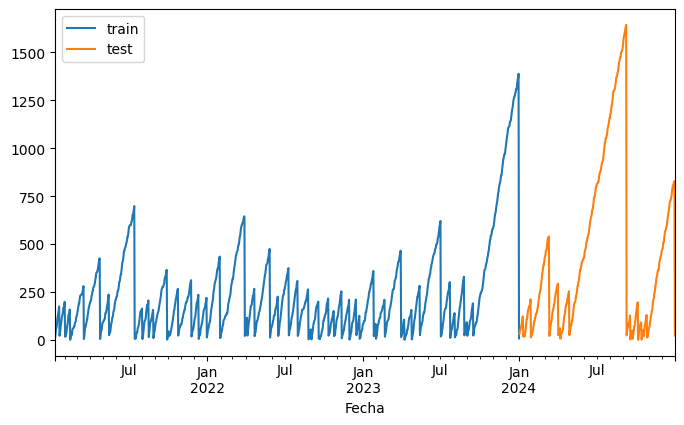

In [10]:
steps = 365
datos_train = df_filtrado_frec[:-steps]
datos_test  = df_filtrado_frec[-steps:]
print(f"Fechas train : {datos_train.index.min()} --- {datos_train.index.max()}  (n={len(datos_train)})")
print(f"Fechas test  : {datos_test.index.min()} --- {datos_test.index.max()}  (n={len(datos_test)})")
 
fig, ax = plt.subplots(figsize=(8, 4.5))
datos_train['Horas_Operativas'].plot(ax=ax, label='train')
datos_test['Horas_Operativas'].plot(ax=ax, label='test')
ax.legend();
 

In [12]:
# Seleccionar la columna 'Horas_Operativas' para la predicción
y = df_filtrado_limpio['Horas_Operativas']

In [13]:
# Dividir los datos en conjuntos de entrenamiento y prueba
train_size = int(len(y) * 0.8)
y_train, y_test = y[:train_size], y[train_size:]

In [14]:
# Crear y entrenar el modelo de suavizamiento exponencial
model = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=15)
fit = model.fit()

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [15]:
# Predecir los próximos 15 días en el conjunto de prueba
predictions = fit.forecast(steps=len(y_test))

In [16]:
# Calcular métricas
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
accuracy = r2 * 100  # Usando el coeficiente de determinación como proxy para la precisión

In [17]:
# Calcular la puntuación F1 (para tareas de clasificación, necesitamos binarizar los datos)
threshold = y_train.mean()  # Ejemplo de umbral para binarización
y_test_binary = (y_test > threshold).astype(int)
predictions_binary = (predictions > threshold).astype(int)
f1 = f1_score(y_test_binary, predictions_binary)

In [18]:
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")
print(f"Accuracy: {accuracy}%")
print(f"F1 Score: {f1}")

Mean Squared Error: 609783.0913097945
R2 Score: -1.8261536863573897
Accuracy: -182.61536863573897%
F1 Score: 0.0


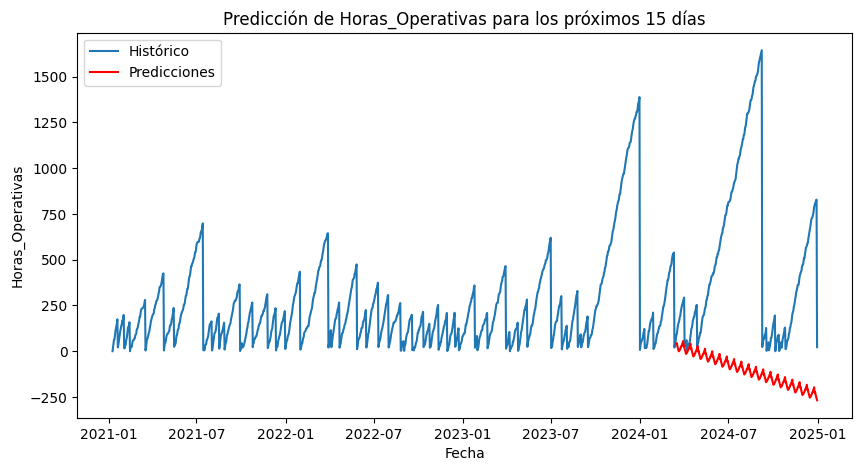

In [19]:
# Visualizar las predicciones
plt.figure(figsize=(10, 5))
plt.plot(y.index, y, label='Histórico')
plt.plot(predictions.index, predictions, label='Predicciones', color='red')
plt.xlabel('Fecha')
plt.ylabel('Horas_Operativas')
plt.title('Predicción de Horas_Operativas para los próximos 15 días')
plt.legend()
plt.show()

In [20]:
# Imprimir predicciones
print(predictions)

2024-03-16     40.513609
2024-03-17     44.354921
2024-03-18     29.247347
2024-03-19     18.427856
2024-03-20      5.236102
                 ...    
2024-12-27   -222.494145
2024-12-28   -237.601719
2024-12-29   -248.421210
2024-12-30   -261.612964
2024-12-31   -267.739396
Freq: D, Length: 291, dtype: float64


In [21]:
# Verificar si el modelo cumple con la precisión y la puntuación F1 requeridas
if accuracy >= 80 and f1 >= 0.75:
    print("El modelo cumple con la precisión y la puntuación F1 requeridas.")
else:
    print("El modelo no cumple con la precisión y la puntuación F1 requeridas. Se necesita más optimización.")

El modelo no cumple con la precisión y la puntuación F1 requeridas. Se necesita más optimización.
